In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pickle

%matplotlib inline
warnings.filterwarnings('ignore')

In [58]:
train = pd.read_csv('aug_train.csv')
train.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


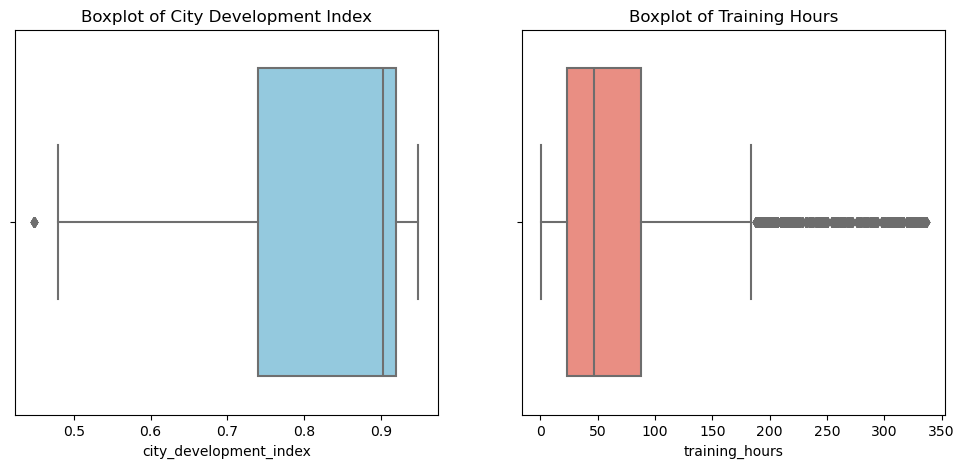

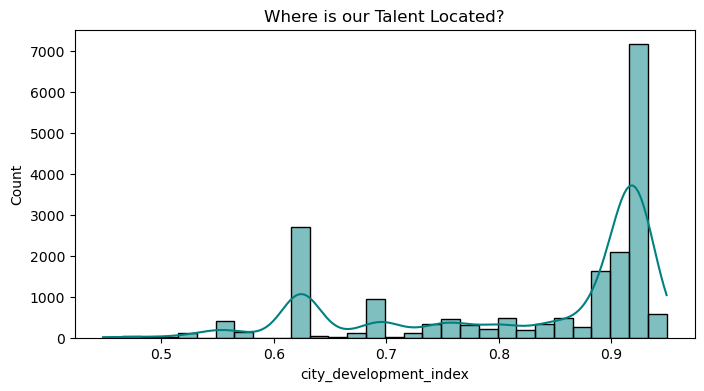

In [59]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=train['city_development_index'], color='skyblue')
plt.title('Boxplot of City Development Index')

plt.subplot(1, 2, 2)
sns.boxplot(x=train['training_hours'], color='salmon')
plt.title('Boxplot of Training Hours')
plt.show()

# Histplot of the landscape
plt.figure(figsize=(8, 4))
sns.histplot(train['city_development_index'], kde=True, color='teal', bins=30)
plt.title('Where is our Talent Located?')
plt.show()

In [60]:
# Filling Categorical with "Unknown" or Mode
train['gender'] = train['gender'].fillna('Unknown')
train['major_discipline'] = train['major_discipline'].fillna('not specified')
train['company_size'] = train['company_size'].bfill() # Using your backfill method

# Filling Numerical with Median
train['city_development_index'] = train['city_development_index'].fillna(train['city_development_index'].median())

In [61]:
def detect_outliers_iqr(data):
    data = sorted(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return lower_bound, upper_bound

lower, upper = detect_outliers_iqr(train['city_development_index'].dropna())
print(f"Outlier Bounds: {lower} to {upper}")

Outlier Bounds: 0.4699999999999999 to 1.1900000000000002


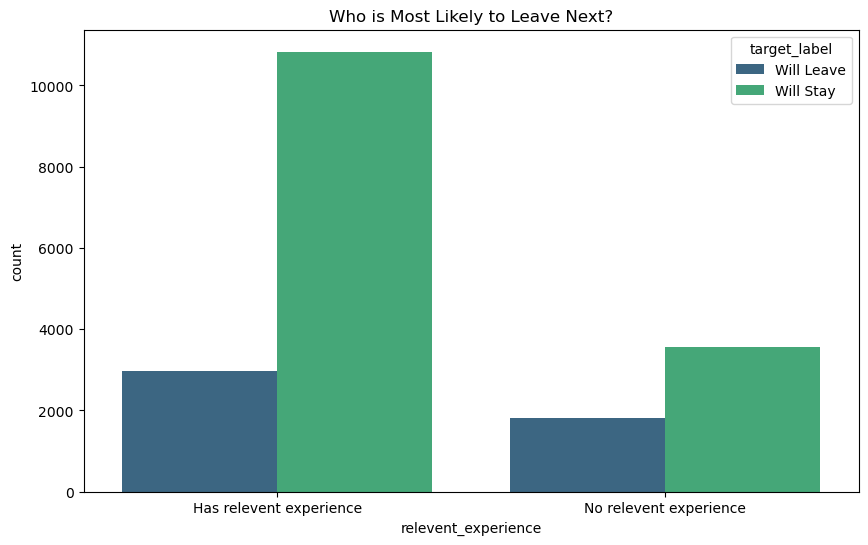

In [62]:
train['target_label'] = train['target'].map({0: 'Will Stay', 1: 'Will Leave'})

plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='relevent_experience', hue='target_label', palette='viridis')
plt.title('Who is Most Likely to Leave Next?')
plt.show()

In [63]:
le = LabelEncoder()
# Encoding 'relevent_experience'
train['relevent_experience_enc'] = le.fit_transform(train['relevent_experience'])

# Encoding 'education_level' (using your mapping)
edu_map = {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
train['education_enc'] = train['education_level'].map(edu_map).fillna(2) # Default to Graduate if NaN

--- Final Model Performance ---
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      2880
         1.0       0.56      0.39      0.46       952

    accuracy                           0.77      3832
   macro avg       0.69      0.64      0.66      3832
weighted avg       0.75      0.77      0.76      3832



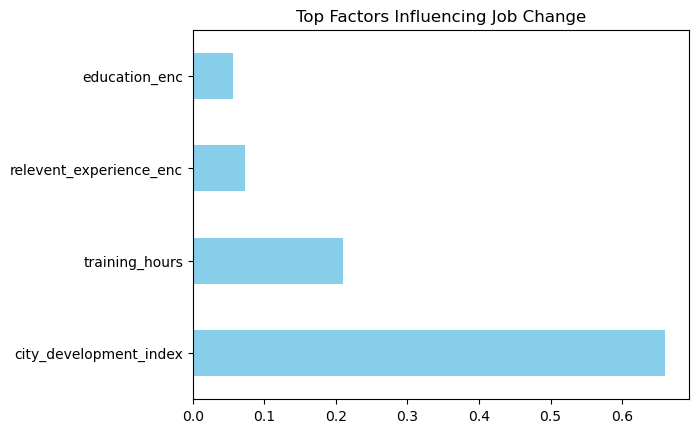

In [64]:
# Selecting the best features
features = ['city_development_index', 'training_hours', 'relevent_experience_enc', 'education_enc']
X = train[features]
y = train['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training
final_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
final_model.fit(X_train, y_train)

# Evaluation
y_pred = final_model.predict(X_test)
print("--- Final Model Performance ---")
print(classification_report(y_test, y_pred))

# Importance Plot
pd.Series(final_model.feature_importances_, index=features).nlargest(4).plot(kind='barh', color='skyblue')
plt.title('Top Factors Influencing Job Change')
plt.show()

![Machine Learning](ml_chart.png)

In [65]:
with open('hr_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)
print("Model saved successfully!")

Model saved successfully!
